# Insect wave with librosa test

## load wave data

[What does librosa.load return?](https://stackoverflow.com/questions/61986490/what-does-librosa-load-return)

[librosa.load api doc](https://librosa.org/doc/latest/generated/librosa.load.html#librosa.load)

In [1]:
import librosa
import numpy as np
from numpy.typing import NDArray
from typing import Tuple, Callable
import math
import logging
from sklearn.preprocessing import minmax_scale
import pywt
import os
import sys

l_fmt = '[%(levelname)s] %(asctime)s - %(message)s'
logging.basicConfig(level=logging.ERROR, format=l_fmt)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

SOUND_FOLDER = '../data/sound/grasshopper-sound-4/'
WAV_PATH = f'{SOUND_FOLDER}/gh-5.wav'
orig_sr = librosa.get_samplerate(WAV_PATH)
logger.info(f'orginal sample rate is: {orig_sr}')

def get_wav_fix_duration(y: NDArray[np.float32], sr: int, fix_func: Callable) -> int:
    duration = librosa.get_duration(y=y, sr=sr)
    logger.debug(f'sound duration: {duration}')
    duration = int(fix_func(duration))
    logger.debug(f'sound fix duration: {duration}')

    return duration

def load_wave(fn: str) -> Tuple[NDArray[np.float32], int, int, int]:
    data, sr = librosa.load(fn, mono=True)
    logger.info(f'data shape: {data.shape}')
    logger.info(f'data type: {data.dtype}')
    logger.info(f'sr: {sr}')
    # TIME = get_wav_fix_duration(data, sr, math.ceil)
    time = get_wav_fix_duration(data, sr, math.floor)
    data = librosa.util.fix_length(data, size=sr*time)
    n = data.shape[0]
    logger.info(f'N is {n}')
    print(data[2000:2020])
    data = minmax_scale(data-data.mean(), feature_range=(-1,1))
    print(data[2000:2020])

    return data, sr, time, n

data, sr, TIME, N = load_wave(WAV_PATH)
print(f'TIME: {TIME} sec')
print(type(data))
print(f'type of array: {data.dtype}')

[INFO] 2022-10-14 23:10:30,655 - orginal sample rate is: 44100
[INFO] 2022-10-14 23:10:31,157 - data shape: (173054,)
[INFO] 2022-10-14 23:10:31,157 - data type: float32
[INFO] 2022-10-14 23:10:31,157 - sr: 22050
[DEBUG] 2022-10-14 23:10:31,158 - sound duration: 7.848253968253968
[DEBUG] 2022-10-14 23:10:31,158 - sound fix duration: 7
[INFO] 2022-10-14 23:10:31,158 - N is 154350


[-8.3298282e-06  7.7250616e-06 -2.9893915e-06 -3.5881567e-06
  2.0156040e-06 -1.5384524e-06  3.4855195e-06 -5.0270933e-06
 -1.9732457e-07  5.4108600e-06 -3.9705469e-06 -3.4404152e-06
  8.7948938e-06 -7.3654924e-06 -1.5095152e-06  9.4686384e-06
 -7.8075409e-06  4.0517248e-06  3.5989362e-06 -4.4384756e-06]
[-0.02141092 -0.02139025 -0.02140404 -0.02140481 -0.0213976  -0.02140217
 -0.02139571 -0.02140667 -0.02140045 -0.02139323 -0.02140531 -0.02140462
 -0.02138887 -0.02140968 -0.02140214 -0.02138801 -0.02141024 -0.02139498
 -0.02139556 -0.02140591]
TIME: 7 sec
<class 'numpy.ndarray'>
type of array: float32


## Play the sound wave

In [2]:
import IPython
# IPython.display.Audio(WAV_PATH)
IPython.display.Audio(data=data, rate=sr)

## plot wave

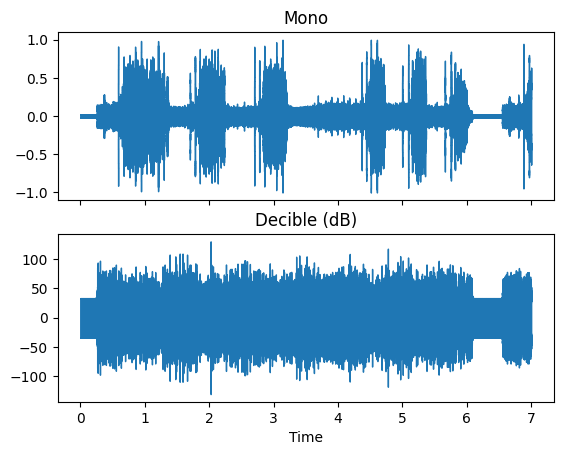

In [3]:

import matplotlib.pyplot as plt
import librosa.display

fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
# plt.figure()
# plt.subplot(3, 1, 2)
librosa.display.waveshow(y=data, sr=sr, ax=ax[0])
librosa.display.waveshow(y=20*np.log10(np.abs(data)), sr=sr, ax=ax[1])
ax[0].set(title='Mono')
ax[0].label_outer()
ax[1].set(title='Decible (dB)')
ax[0].label_outer()


## Plot sound wave spectrogram

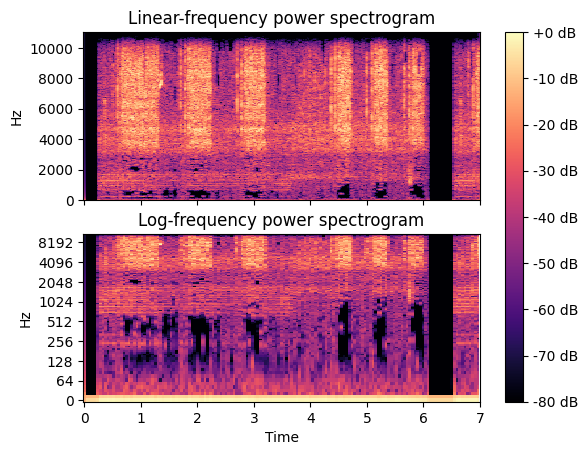

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
D = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
img = librosa.display.specshow(D, y_axis='linear', x_axis='time',
                               sr=sr, ax=ax[0])
ax[0].set(title='Linear-frequency power spectrogram')
ax[0].label_outer()

hop_length = 1024
D = librosa.amplitude_to_db(np.abs(librosa.stft(data, hop_length=hop_length)),
                            ref=np.max)
librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length,
                         x_axis='time', ax=ax[1])
ax[1].set(title='Log-frequency power spectrogram')
ax[1].label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

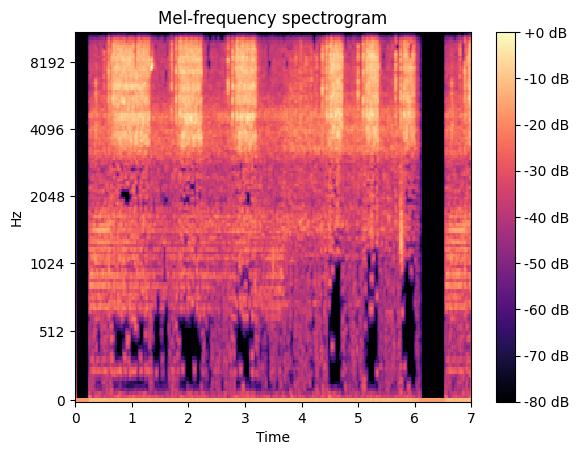

In [5]:
F_MAX = sr // 2
S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128, fmax=F_MAX)

fig, ax = plt.subplots()
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, fmax=F_MAX, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

## Manual scalogram plot

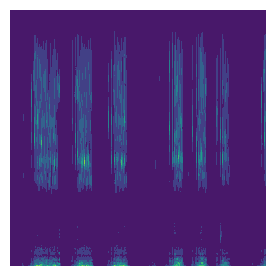

In [6]:
sys.path.insert(0, os.path.abspath('../src'))
from cwt import plot_scalogram

plot_scalogram(data, sr)

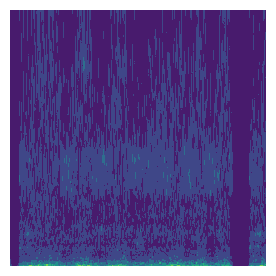

In [7]:

plot_scalogram(data, sr, db=True)

shape of cs1: (97, 154350)
cs1:
[-0.01651503-1.35047660e-02j  0.01186272-1.70507491e-02j
  0.01607042+9.84163990e-03j -0.00776357+1.37700595e-02j
 -0.01054001-5.89817971e-03j  0.00440716-6.89077530e-03j
  0.00335581+3.31791453e-03j -0.00253017+3.92017156e-04j
  0.0017015 -1.85146361e-03j  0.00105191+2.82990711e-03j
 -0.00310511-7.50613557e-05j  0.00166025-2.80562520e-03j
  0.00230595+3.72650495e-03j -0.0061824 +1.99404888e-03j
 -0.0021948 -8.83979896e-03j  0.01144764-3.11111183e-03j
  0.0047877 +1.37330904e-02j -0.01544398+7.09900198e-03j
 -0.00976251-1.63893473e-02j  0.01647537-1.23787389e-02j]
shape of f1: (97,)


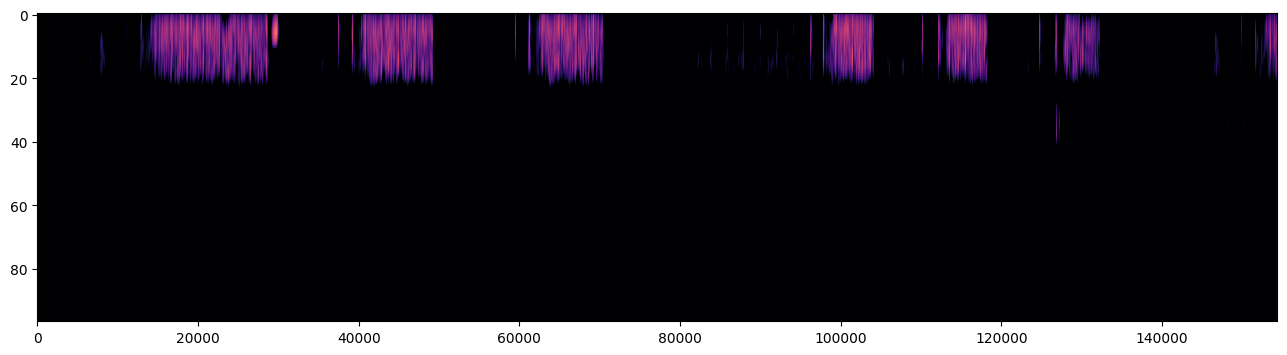

In [9]:
from cwt import cwt2

CMAP = 'magma'

cs1, f1 = cwt2(data, nv=12, sr=sr, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

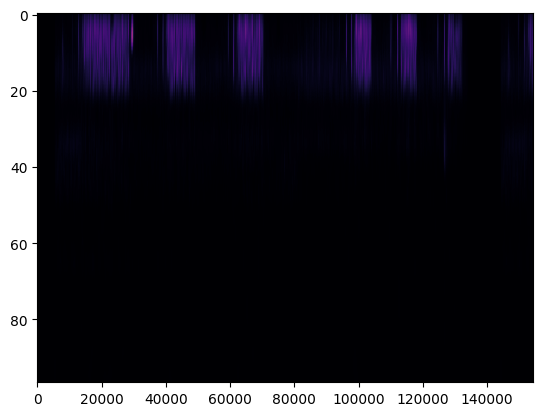

In [11]:
plt.imshow(np.abs(cs1), cmap=CMAP, aspect='auto', norm=None)
plt.show()

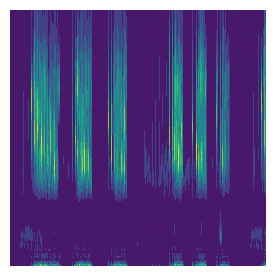

In [8]:
plot_scalogram(data, sr, wavename='cmor3.0-1.0')

## another grasshopper

In [9]:
wav_fn  = f'{SOUND_FOLDER}/gh-4.wav'
data, sr, TIME, N = load_wave(wav_fn)
IPython.display.Audio(data=data, rate=sr)

[INFO] 2022-10-14 23:11:58,682 - data shape: (228217,)
[INFO] 2022-10-14 23:11:58,683 - data type: float32
[INFO] 2022-10-14 23:11:58,684 - sr: 22050
[DEBUG] 2022-10-14 23:11:58,684 - sound duration: 10.349977324263039
[DEBUG] 2022-10-14 23:11:58,684 - sound fix duration: 10
[INFO] 2022-10-14 23:11:58,685 - N is 220500


[-0.00020739  0.00178727  0.00401311  0.00555956  0.00518426  0.00372737
  0.00138277 -0.00124355 -0.00341179 -0.00261917 -0.00171792 -0.00301276
 -0.00330138 -0.00370603 -0.00434046 -0.00358419 -0.00284869 -0.00172745
 -0.00071639 -0.00296467]
[-0.04603487 -0.03503509 -0.02276038 -0.01423231 -0.01630197 -0.02433614
 -0.03726575 -0.05174892 -0.06370594 -0.05933489 -0.05436489 -0.06150539
 -0.06309704 -0.06532855 -0.06882717 -0.06465665 -0.0606006  -0.05441742
 -0.0488418  -0.06124021]


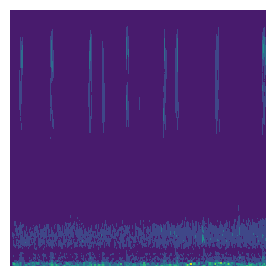

In [11]:
plot_scalogram(data, sr)

In [14]:
wav_fn2  = f'{SOUND_FOLDER}/gh-2.wav'
data, sr, TIME, N = load_wave(wav_fn2)
IPython.display.Audio(data=data, rate=sr)

[INFO] 2022-10-14 23:13:54,887 - data shape: (217499,)
[INFO] 2022-10-14 23:13:54,888 - data type: float32
[INFO] 2022-10-14 23:13:54,888 - sr: 22050
[DEBUG] 2022-10-14 23:13:54,889 - sound duration: 9.86390022675737
[DEBUG] 2022-10-14 23:13:54,889 - sound fix duration: 9
[INFO] 2022-10-14 23:13:54,889 - N is 198450


[ 0.00291999  0.00036749 -0.00051794  0.00284899  0.0021038   0.0025918
  0.0008273  -0.00026795  0.00289488  0.00205396  0.00154049  0.00019216
  0.0003697   0.0033542   0.00195121 -0.00021067 -0.0006294   0.00070928
  0.00064513 -0.00081898]
[0.0260815  0.02304993 0.02199831 0.02599718 0.02511212 0.02569172
 0.02359604 0.02229522 0.02605168 0.02505293 0.02444309 0.02284169
 0.02305255 0.02659722 0.0249309  0.02236325 0.02186593 0.02345587
 0.02337968 0.02164077]


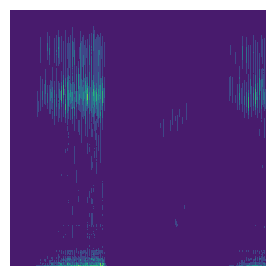

In [15]:
plot_scalogram(data, sr)
